## Introduction
<b>AI201</b><br /> 
<b>Programming Assignment 1</b><br /> 
<b>Implementing the A* Algorithm</b><br /> 
Instructor(s): Dr. Pros Naval & Dr. Lyn Gabud<br /> 
Name: Deomary Angelo Franco<br />


The A* (A star) algorithm will be implemented here from scratch using purely Python on Jupyter Notebook (with some packages). The algorithm will be used to solve the 8-Puzzle Problem. Input here will be a text file. The algorithm will be performed on 3 different Heuristic functions, namely:
- Number of Tiles in the Wrong Position
- Manhattan Distance
- Nilsson's Sequence Score

## Import Functions
Below are the packages used for this implementation. Numpy is mostly used to easily structure the data such that moving along rows or columns will be easier. Matplotlib and IPython is to visually present the solution via a simple animation. Lastly, time package is used to record the speed of the implementation on the local machine.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

## Heuristic Functions

In [2]:
def _wrong_count(current, goal):
    """
    Heuristic function which solves the number of tiles that are of incorrect
    placement.
    """
    total = (current != goal).sum()
    return total, 0, 0


def _manhattan(current, goal):
    """
    Heuristic function which solves the summation of manhattan distance from
    current tile to goal tile.
    """
    total = 0
    for num in range(1, 9):
        x1, y1 = np.where(current == str(num))
        x2, y2 = np.where(goal == str(num))
        total += abs(x1[0] - x2[0]) + abs(y1[0] - y2[0])
    return total, 0, 0
    

def _nilsson(current, goal):
    """
    Heuristic function that gives P(n) + 3*S(n) where P(n) is the manhattan
    distance and S(n) is a function of central tile and the clockwise tile.
    """
    cw_index_dict = {
        (0, 0): (0, 1),
        (0, 1): (0, 2),
        (0, 2): (1, 2),
        (1, 2): (2, 2),
        (2, 2): (2, 1),
        (2, 1): (2, 0),
        (2, 0): (1, 0),
        (1, 0): (0, 0)
    }
    center_index = (1, 1)
    p = 0
    s = 0

    for num in range(1, 9):
        x1, y1 = np.where(current == str(num))
        x2, y2 = np.where(goal == str(num))
        dist = abs(x1[0] - x2[0]) + abs(y1[0] - y2[0])
        p += dist

        is_center = (x1, y1) == center_index

        if is_center:
            offcenter = 1
            s += offcenter
            
        elif not is_center :
            element_in_cw = current[cw_index_dict[(int(x1[0]), int(y1[0]))]]
            expected_element_in_cw = str(int(num) + 1) if num != 8 else '1'
            is_clockwise_expected = element_in_cw == expected_element_in_cw
            
            if not is_clockwise_expected:
                not_cw = 2
                s += not_cw

    total = p + 3*s
    return total, p, s


def heuristic(current, goal, kind='wrong_count'):
    """
    Computes for the number of tiles that are incorrect.
    """

    if kind == 'wrong_count':
        total, p, s = _wrong_count(current, goal)
    
    if kind == 'manhattan':
        total, p, s = _manhattan(current, goal)
    
    if kind == 'nilsson':
        total, p, s = _nilsson(current, goal)

    return total, p, s

## Useful functions

In [3]:
def parse_file(input_file, shape=(3, 3)):
    """
    Takes the input_file and splits it into 2 numpy arrays which are named
    start and goal.
    """
    
    with open(input_file, 'r') as file:
        lines = file.readlines()

    start, goal = [], []
    current = None

    for line in lines:
        line = line.strip().split(' ')
        if 'start' in line:
            current = 'start'
        elif 'goal' in line:
            current = 'goal'
        else:
            if current == 'start':
                start.append(line)
            elif current == 'goal':
                goal.append(line)

    start = np.array(start).reshape(shape)
    goal = np.array(goal).reshape(shape)

    return start, goal


def move_star(current_state, direction):
    """
    Moves the empty square (*) to the stated direction. Returns the tuple
    (new_state, moved). moved is True if the provided direction is valid else
    False.
    """

    i, j = np.where(current_state=='*')
    up_edge, left_edge = 0, 0
    down_edge, right_edge  = current_state.shape
    
    new_state = current_state.copy()
    up_limit, down_limit = i==up_edge, i==down_edge-1
    left_limit, right_limit = j==left_edge, j==right_edge-1
    switch_index = None
    moved = False

    if direction == 'up' and not up_limit:
        switch_index = i-1, j
    elif direction == 'down' and not down_limit:
        switch_index = i+1, j
    elif direction == 'left' and not left_limit:
        switch_index = i, j-1
    elif direction == 'right' and not right_limit:
        switch_index = i, j+1

    if switch_index:
        new_state[switch_index], new_state[i, j] = (
            current_state[i, j], 
            current_state[switch_index]
        )
        moved = True
    
    return new_state, moved


def draw_puzzle(state):
    """
    Displays the current puzzle state as a grid.
    """
    grid = np.array(state).reshape(3, 3)
    _, ax = plt.subplots(figsize=(3, 3))
    
    ax.imshow(np.ones((3,3)), cmap="gray", extent=[0, 3, 0, 3])
    
    for i in range(3):
        for j in range(3):
            value = grid[i, j]
            if value != '*':
                ax.text(
                    j + .5, 2.5 - i,
                    str(value), 
                    ha='center', 
                    va='center', 
                    fontsize=22, 
                    bbox=dict(
                        boxstyle="square,pad=.6",
                        edgecolor="black", 
                        facecolor="white"
                    )
                )

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


def animate_solution(solution_path, delay=.2):
    """
    Animate the solution step-by-step inside a Jupyter notebook.
    """
    for state in solution_path:
        clear_output(wait=True)
        draw_puzzle(state)
        time.sleep(delay)


## A-star (A*) Algorithm

In [ ]:
def a_star(start, goal, kind):
    """
    Implements A* algorithm based on provided pseudocode.
    """

    t1 = time.time()
    OPEN = []
    CLOSED = set()
    parent = {}  
    step = 1
    start_tuple = tuple(map(tuple, start))

    # Step 1: Put on Open together with f
    g_values = {start_tuple: 0} 
    g = g_values[start_tuple]
    h, p, s = heuristic(start, goal, kind)
    f = g + h
    OPEN.append((f, start_tuple))

    # Step 2: Exit if empty else continue
    while OPEN:
        # Step 3: Remove the node with smallest f
        OPEN.sort(key=lambda x: x[0])  
        _, n_tuple = OPEN.pop(0)
        n = np.array(n_tuple)
        g = g_values[n_tuple]
        h, p, s = heuristic(n, goal, kind)
        f = g + h
        CLOSED.add(n_tuple)
        
        print((f'STEP {step} | f(n): {f} | g(n): {g} | h(n): {h} |' 
        f'P(n): {p} | S(n): {s}'))
        step += 1

        # Step 4: If goal, exit with solution
        if np.array_equal(n, goal):
            print("Goal Reached!")
            path = [n_tuple]
            key = n_tuple
            while key in parent:
                key = parent[key]
                path.append(np.array(key).reshape(n.shape))
    
            path.reverse()
            path.append(goal.reshape(n.shape))
            t2 = time.time()

            print()
            print(f'Time Taken: {(t2 - t1):.4f}')
            print(f'Search cost: {len(CLOSED) + len(set(OPEN))} nodes')
            print(f'f(n): {f} | g(n): {g} | h(n): {h} | P(n): {p} | S(n): {s}')

            return path

        # Step 5: Expand nodes with successors.
        successors = []
        for move in ['up', 'right', 'down', 'left']:
            n1, moved = move_star(n, move)
            if moved:
                successors.append(n1)

        # Step 6: Associate with successors not in OPEN or CLOSED the f values.
        for n1 in successors:
            n1_tuple = tuple(map(tuple, n1))
            g = g_values[n_tuple] + 1  

            if n1_tuple in CLOSED:
                continue  
            
            # Step 7: Associate successors not in OPEN or CLOSED the smaller f
            if n1_tuple not in g_values or g < g_values[n1_tuple]:
                g_values[n1_tuple] = g
                h, p, s = heuristic(n1, goal, kind)
                f = g + h
                OPEN.append((f, n1_tuple))   
                parent[n1_tuple] = n_tuple  
 
    # Step 8:
    print("Failure: No path found.")
    return


## Number of Tiles in the Wrong Position
The block of code here will perform A* with input as "astar_in.txt" with heuristic function as the number of tiles in the wrong position.
f(n), g(n), h(n) will also be printed per step. For this heuristic, P(n) & S(n) is printed but as zero since there is no such value for this heuristic. The next cell will show an animation of the solution.

In [12]:
start, goal = parse_file('astar_in.txt', (3, 3))
result = a_star(start, goal, 'wrong_count')

STEP 1 | f(n): 7 | g(n): 0 | h(n): 7 |P(n): 0 | S(n): 0
STEP 2 | f(n): 9 | g(n): 1 | h(n): 8 |P(n): 0 | S(n): 0
STEP 3 | f(n): 9 | g(n): 1 | h(n): 8 |P(n): 0 | S(n): 0
STEP 4 | f(n): 9 | g(n): 1 | h(n): 8 |P(n): 0 | S(n): 0
STEP 5 | f(n): 9 | g(n): 1 | h(n): 8 |P(n): 0 | S(n): 0
STEP 6 | f(n): 9 | g(n): 2 | h(n): 7 |P(n): 0 | S(n): 0
STEP 7 | f(n): 10 | g(n): 2 | h(n): 8 |P(n): 0 | S(n): 0
STEP 8 | f(n): 10 | g(n): 2 | h(n): 8 |P(n): 0 | S(n): 0
STEP 9 | f(n): 10 | g(n): 2 | h(n): 8 |P(n): 0 | S(n): 0
STEP 10 | f(n): 10 | g(n): 2 | h(n): 8 |P(n): 0 | S(n): 0
STEP 11 | f(n): 10 | g(n): 2 | h(n): 8 |P(n): 0 | S(n): 0
STEP 12 | f(n): 10 | g(n): 3 | h(n): 7 |P(n): 0 | S(n): 0
STEP 13 | f(n): 10 | g(n): 3 | h(n): 7 |P(n): 0 | S(n): 0
STEP 14 | f(n): 10 | g(n): 3 | h(n): 7 |P(n): 0 | S(n): 0
STEP 15 | f(n): 10 | g(n): 4 | h(n): 6 |P(n): 0 | S(n): 0
STEP 16 | f(n): 10 | g(n): 4 | h(n): 6 |P(n): 0 | S(n): 0
STEP 17 | f(n): 10 | g(n): 4 | h(n): 6 |P(n): 0 | S(n): 0
STEP 18 | f(n): 11 | g(n): 2 

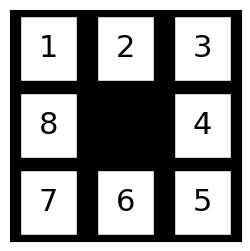

In [18]:
animate_solution(result)

## Manhattan Distance
The block of code here will perform A* with input as "astar_in.txt" with heuristic function as the total manhattan distance from current tile to correct tile.
f(n), g(n), h(n) will also be printed per step. For this heuristic, P(n) & S(n) is printed but as zero since there is no such value for this heuristic. The next cell will show an animation of the solution.

In [14]:
start, goal = parse_file('astar_in.txt', (3, 3))
result = a_star(start, goal, 'manhattan')

STEP 1 | f(n): 12 | g(n): 0 | h(n): 12 |P(n): 0 | S(n): 0
STEP 2 | f(n): 12 | g(n): 1 | h(n): 11 |P(n): 0 | S(n): 0
STEP 3 | f(n): 12 | g(n): 1 | h(n): 11 |P(n): 0 | S(n): 0
STEP 4 | f(n): 12 | g(n): 2 | h(n): 10 |P(n): 0 | S(n): 0
STEP 5 | f(n): 12 | g(n): 2 | h(n): 10 |P(n): 0 | S(n): 0
STEP 6 | f(n): 12 | g(n): 3 | h(n): 9 |P(n): 0 | S(n): 0
STEP 7 | f(n): 14 | g(n): 1 | h(n): 13 |P(n): 0 | S(n): 0
STEP 8 | f(n): 14 | g(n): 1 | h(n): 13 |P(n): 0 | S(n): 0
STEP 9 | f(n): 14 | g(n): 2 | h(n): 12 |P(n): 0 | S(n): 0
STEP 10 | f(n): 14 | g(n): 2 | h(n): 12 |P(n): 0 | S(n): 0
STEP 11 | f(n): 14 | g(n): 3 | h(n): 11 |P(n): 0 | S(n): 0
STEP 12 | f(n): 14 | g(n): 4 | h(n): 10 |P(n): 0 | S(n): 0
STEP 13 | f(n): 14 | g(n): 4 | h(n): 10 |P(n): 0 | S(n): 0
STEP 14 | f(n): 14 | g(n): 2 | h(n): 12 |P(n): 0 | S(n): 0
STEP 15 | f(n): 14 | g(n): 2 | h(n): 12 |P(n): 0 | S(n): 0
STEP 16 | f(n): 14 | g(n): 3 | h(n): 11 |P(n): 0 | S(n): 0
STEP 17 | f(n): 14 | g(n): 4 | h(n): 10 |P(n): 0 | S(n): 0
STEP 18

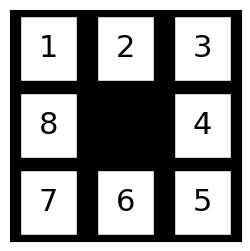

In [15]:
animate_solution(result)

## Nilsson's Sequence Score: h(n) = P(n) + 3S(n)
The block of code here will perform A* with input as "astar_in.txt" with heuristic function as Nilsson's Sequence Score.
f(n), g(n), h(n) will also be printed per step. For this heuristic, P(n) & S(n) is also shown. The next cell will show an animation of the solution.

In [16]:
start, goal = parse_file('astar_in.txt', (3, 3))
result = a_star(start, goal, 'nilsson')

STEP 1 | f(n): 60 | g(n): 0 | h(n): 60 |P(n): 12 | S(n): 16
STEP 2 | f(n): 57 | g(n): 1 | h(n): 56 |P(n): 11 | S(n): 15
STEP 3 | f(n): 57 | g(n): 1 | h(n): 56 |P(n): 11 | S(n): 15
STEP 4 | f(n): 57 | g(n): 2 | h(n): 55 |P(n): 10 | S(n): 15
STEP 5 | f(n): 57 | g(n): 2 | h(n): 55 |P(n): 10 | S(n): 15
STEP 6 | f(n): 57 | g(n): 3 | h(n): 54 |P(n): 9 | S(n): 15
STEP 7 | f(n): 59 | g(n): 1 | h(n): 58 |P(n): 13 | S(n): 15
STEP 8 | f(n): 59 | g(n): 1 | h(n): 58 |P(n): 13 | S(n): 15
STEP 9 | f(n): 59 | g(n): 2 | h(n): 57 |P(n): 12 | S(n): 15
STEP 10 | f(n): 59 | g(n): 2 | h(n): 57 |P(n): 12 | S(n): 15
STEP 11 | f(n): 59 | g(n): 3 | h(n): 56 |P(n): 11 | S(n): 15
STEP 12 | f(n): 58 | g(n): 4 | h(n): 54 |P(n): 12 | S(n): 14
STEP 13 | f(n): 55 | g(n): 5 | h(n): 50 |P(n): 11 | S(n): 13
STEP 14 | f(n): 55 | g(n): 5 | h(n): 50 |P(n): 11 | S(n): 13
STEP 15 | f(n): 55 | g(n): 6 | h(n): 49 |P(n): 10 | S(n): 13
STEP 16 | f(n): 55 | g(n): 7 | h(n): 48 |P(n): 9 | S(n): 13
STEP 17 | f(n): 46 | g(n): 8 | h(n)

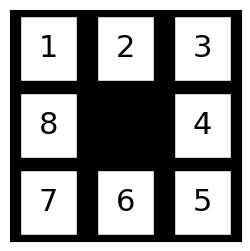

In [17]:
animate_solution(result)

## Summary

| Heuristic | Time (seconds) | Search Cost (nodes) | Time Ratio against Wrong Count (%) | Search Cost Ratio against Wrong Count (%) |
| -------- | ------- | ------- | ------- | ------- |
| Wrong Count  | 0.2410 | 3168 | 100 | 100 | 
| Manhattan | 0.0504| 379 | 20.1 | 12.0 | 
| Nilsson    | 0.0100 | 59 | 4.1 | 1.9 |

Note: Time here could vary depending on machine specifications.

Based from the utilized heuristic functions for the A* algorithm, it can be observed that Nilsson's Sequence Score is the most efficient in both time and Search Cost albeit the most complicated to implement due to more computations performed per step. But since it has the least number of steps, it is arguably the cheapest in an overall standpoint.